# 3) Learning Detection — Sequence Criterion (Strategy 1)

This notebook demonstrates the **Sequence Criterion** learning detection method (Figure 3, “Strategy 1” in the paper).



In [8]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure
from Functions.interpolate_null_trials import interpolate_null_trials

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

# Load + standardize
from config import data_path, prior_type, decay_rate, save_output_csv, strategy_name
from Functions.standardize_dataset import standardize_dataset

TestData = pd.read_csv(data_path)
TestData = standardize_dataset(TestData)
no_Trials = len(TestData)


In [9]:
# Load test data



no_Trials = len(TestData)

# Strategies shown in Figure 1
strategies = [
    "go_left",
    "go_right",
    "go_cued",
    "win_stay_spatial",
    "lose_shift_cued",
    "lose_shift_spatial"
]
rule_strategies = ["go_left", "go_right", "go_cued"]


strategy_functions = {}
for s in strategies:
    try:
        strategy_functions[s] = getattr(strategymodels, s)
    except AttributeError:
        raise ValueError(f"Strategy '{s}' not found in strategymodels.")



TestData.head()

,TrialIndex,Choice,CuePosition,Reward
0,1,left,left,yes
1,2,left,left,yes
2,3,left,left,yes
3,4,left,left,yes
4,5,left,left,yes


In [10]:
# Initialise storage
alpha0, beta0 = set_priors(prior_type) 

Output_collection = {}
event_totals = {}

for strategy in strategies:
    
    Output_collection[strategy] = pd.DataFrame(
        columns=[
            "Alpha", "Beta",
            "MAPprobability", "Precision",
            "Alpha_interpolated", "Beta_interpolated",
            "MAPprobability_interpolated", "Precision_interpolated"
        ]
    )
    
    event_totals[strategy] = {
        "success_total": 0,
        "failure_total": 0
    }

In [11]:
# Run Bayesian strategy analysis across trials

for trial in range(len(TestData)):
    
    rows_of_data = TestData.iloc[0:trial+1]
    
    for strategy in strategies:
        
        strategy_fcn = getattr(strategymodels, strategy)
        trial_type = strategy_fcn(rows_of_data)
        
        success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
            trial_type,
            decay_rate,
            event_totals[strategy]["success_total"],
            event_totals[strategy]["failure_total"],
            alpha0,
            beta0
        )
        
        event_totals[strategy]["success_total"] = success_total
        event_totals[strategy]["failure_total"] = failure_total
        
        MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
        precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")
        
        this_trials_data = {
            "Alpha": Alpha,
            "Beta": Beta,
            "MAPprobability": MAPprobability,
            "Precision": precision
        }
        
        if trial > 0:
            previous_trials_data = Output_collection[strategy].iloc[trial-1]
        else:
            previous_trials_data = Output_collection[strategy]
        
        new_row_of_data = interpolate_null_trials(
            this_trials_data,
            previous_trials_data,
            alpha0,
            beta0
        )
        
        Output_collection[strategy] = pd.concat(
            [Output_collection[strategy], pd.DataFrame([new_row_of_data])],
            ignore_index=True
        )

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_14140/3955232189.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Output_collection[strategy] = pd.concat(


In [12]:
final_MAPs = {
    s: Output_collection[s]["MAPprobability"].iloc[-1]
    for s in rule_strategies
}
dominant_rule = max(final_MAPs, key=final_MAPs.get)

print("Final MAP (rule strategies):", final_MAPs)
print("Dominant rule strategy:", dominant_rule)

Final MAP (rule strategies): {'go_left': np.float64(0.14), 'go_right': np.float64(0.86), 'go_cued': np.float64(0.999)}
Dominant rule strategy: go_cued


In [13]:
def detect_learning_sequence(map_prob, chance_level=0.5):
    """
    Sequence criterion (paper-compatible):
    Return the first trial t such that MAP(t:) > chance_level for all remaining trials.
    """
    map_prob = np.asarray(map_prob)

    for t in range(len(map_prob)):
        if np.all(map_prob[t:] > chance_level):
            mask = np.zeros(len(map_prob), dtype=bool)
            mask[t:] = True
            return t, mask

    return None, np.zeros(len(map_prob), dtype=bool)

In [14]:
chance_level = 0.5
MAP = Output_collection[dominant_rule]["MAPprobability"].values

learning_trial, learning_mask = detect_learning_sequence(MAP, chance_level=chance_level)
learning_trial

0

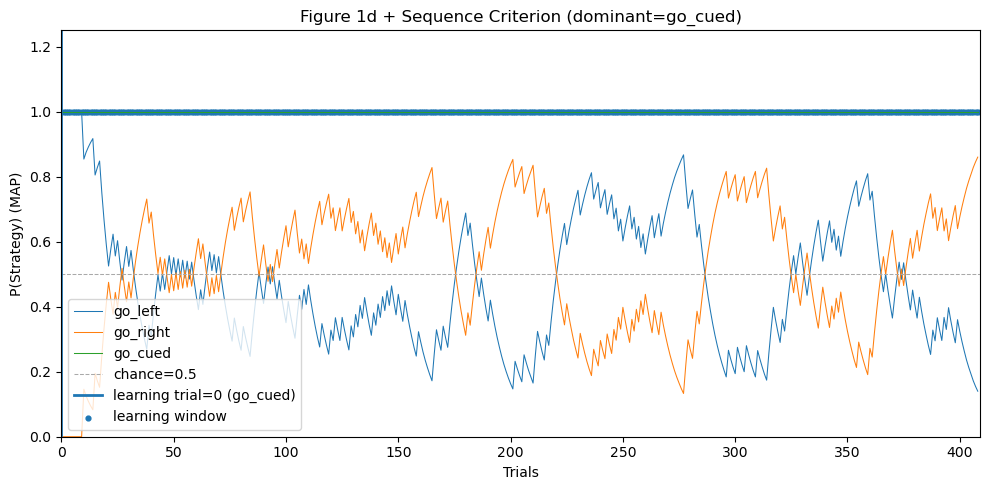

In [15]:
plt.figure(figsize=(10, 5))

for s in rule_strategies:
    plt.plot(Output_collection[s].MAPprobability, linewidth=0.75, label=s)

plt.axhline(y=chance_level, color="darkgrey", linestyle="--", linewidth=0.75, label=f"chance={chance_level}")

if learning_trial is not None:
    plt.axvline(x=learning_trial, linewidth=2, label=f"learning trial={learning_trial} ({dominant_rule})")
    plt.scatter(np.where(learning_mask)[0], MAP[learning_mask], s=12, label="learning window")

plt.xlabel("Trials")
plt.ylabel("P(Strategy) (MAP)")
plt.title(f"Figure 1d + Sequence Criterion (dominant={dominant_rule})")

try:
    plotSessionStructure(TestData)
except Exception:
    pass

plt.axis([0, no_Trials, 0, 1.25])  
plt.legend()
plt.tight_layout()
plt.show()

# NEXT STEP
To compare all three learning criteria, run 4_Learning_Criteria_Comparison.ipynb